# Olist E-Commerce Customer Retention Analysis

## Business Question
**What factors drive customers to make repeat purchases, and what characteristics distinguish one-time buyers from repeat customers?**

## Executive Summary
This analysis examines customer retention patterns in the Olist Brazilian e-commerce dataset spanning September 2016 to August 2018. The dataset reveals an unusually low retention rate of 1.87%, significantly below typical e-commerce benchmarks of 20-40%. Through systematic analysis of operational metrics, order characteristics, product preferences, and geographic patterns, this study investigates what differentiates the small percentage of customers who make repeat purchases.

**Key Finding:** Retained customers show similar characteristics to churned customers across nearly all dimensions analyzed, suggesting that retention drivers in this marketplace may be influenced by factors not captured in the transactional data—such as specific product needs, competitive alternatives, or personal circumstances.

## Dataset Overview
The Olist dataset contains information about orders, customers, products, sellers, and reviews from a Brazilian e-commerce marketplace. Key tables include:
- **Orders**: Order status, timestamps, and customer IDs
- **Customers**: Customer location and unique identifiers
- **Order Items**: Products purchased, prices, and freight costs
- **Products**: Product categories and characteristics
- **Reviews**: Customer satisfaction scores and comments
- **Payments**: Payment methods and values

**Data Structure Note:**
- `customer_unique_id`: The actual unique person identifier
- `customer_id`: A unique identifier per order/address combination

The same person can have multiple `customer_id` values if they order from different addresses, but will maintain the same `customer_unique_id`. This distinction is essential for accurately measuring retention, as failing to account for it would incorrectly classify the same person's repeat purchases as coming from different customers.

In [1]:
# Importing relevant libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# Getting directory where the notebook is located
notebook_dir = Path.cwd()

# Creating path to parent directory containing data files
data_dir = notebook_dir.parent/'data'

# Creating DataFrames for each file
customers = pd.read_csv(data_dir / 'olist_customers_dataset.csv')
geolocation = pd.read_csv(data_dir / 'olist_geolocation_dataset.csv')
order_items = pd.read_csv(data_dir / 'olist_order_items_dataset.csv')
order_payments = pd.read_csv(data_dir / 'olist_order_payments_dataset.csv')
order_reviews = pd.read_csv(data_dir / 'olist_order_reviews_dataset.csv')
orders = pd.read_csv(data_dir / 'olist_orders_dataset.csv')
products = pd.read_csv(data_dir / 'olist_products_dataset.csv')
sellers = pd.read_csv(data_dir / 'olist_sellers_dataset.csv')
product_category = pd.read_csv(data_dir / 'product_category_name_translation.csv')

In [2]:
# Convert timestamp columns to datetime
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_approved_at'] = pd.to_datetime(orders['order_approved_at'])
orders['order_delivered_carrier_date'] = pd.to_datetime(orders['order_delivered_carrier_date'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])

# Adding time features
orders['purchase_month'] = orders['order_purchase_timestamp'].dt.month
orders['purchase_year'] = orders['order_purchase_timestamp'].dt.year
orders['purchase_day_of_week'] = orders['order_purchase_timestamp'].dt.dayofweek

## 2. Defining Customer Retention

### 2.1 Understanding Repeat Purchase Timing
To define an appropriate retention window, we first examine when customers who do make repeat purchases tend to return.

In [3]:
# Merge orders with customer information to get customer_unique_id
orders_with_customer_info = orders.merge(customers, on='customer_id')

# Identify each customer's first purchase date
customer_first_purchase = orders_with_customer_info.groupby('customer_unique_id')['order_purchase_timestamp'].min().reset_index()
customer_first_purchase.rename(columns={'order_purchase_timestamp': 'first_purchase_date'}, inplace=True)

# Merge first purchase date back to orders
orders_with_first = orders_with_customer_info.merge(customer_first_purchase, on='customer_unique_id')

# Calculate days since first purchase
orders_with_first['days_since_first_purchase'] = (
    orders_with_first['order_purchase_timestamp'] - orders_with_first['first_purchase_date']
).dt.days

# Identify repeat purchases (delivered orders only)
orders_with_first['is_repeat_purchase'] = orders_with_first['days_since_first_purchase'] > 0
repeat_purchases = orders_with_first[
    (orders_with_first['is_repeat_purchase'] == True) & 
    (orders_with_first['order_status'] == 'delivered')
]

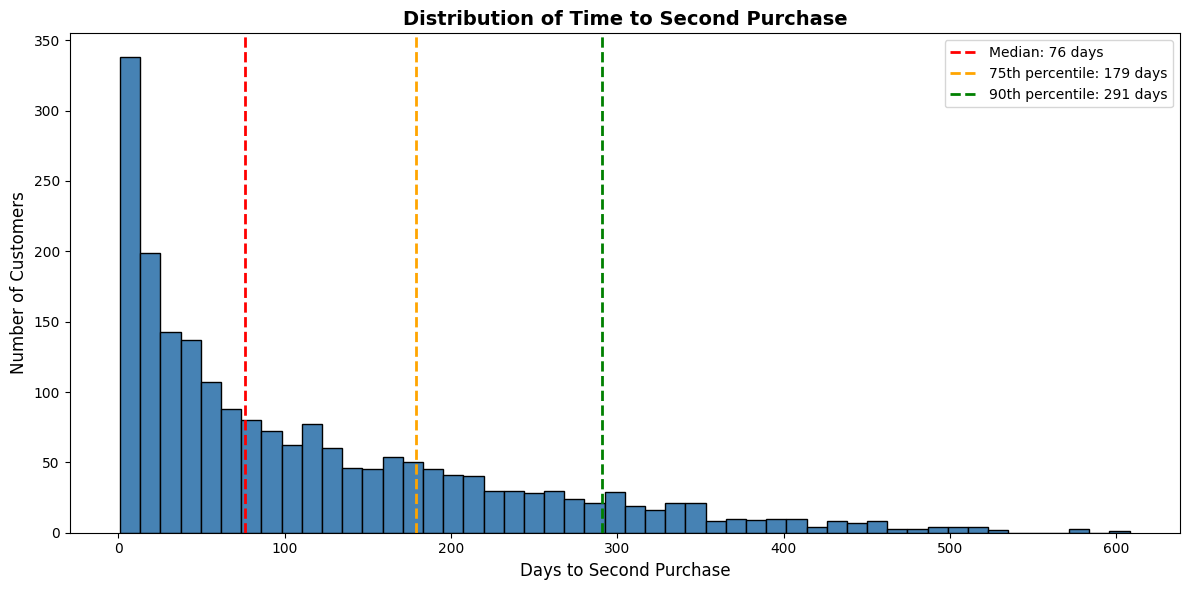

Time to Second Purchase Statistics:
count    2051.000000
mean      116.202828
std       115.684861
min         1.000000
25%        24.000000
50%        76.000000
75%       179.000000
max       608.000000
Name: days_since_first_purchase, dtype: float64


In [4]:
# Analyze time to second purchase for repeat customers
repeat_purchases_second_only = repeat_purchases.groupby('customer_unique_id')['days_since_first_purchase'].min().reset_index()

# Visualize distribution
plt.figure(figsize=(12, 6))
plt.hist(repeat_purchases_second_only['days_since_first_purchase'], bins=50, edgecolor='black', color='steelblue')
plt.xlabel('Days to Second Purchase', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.title('Distribution of Time to Second Purchase', fontsize=14, fontweight='bold')

# Add percentile reference lines
median_days = repeat_purchases_second_only['days_since_first_purchase'].median()
percentile_75 = repeat_purchases_second_only['days_since_first_purchase'].quantile(0.75)
percentile_90 = repeat_purchases_second_only['days_since_first_purchase'].quantile(0.90)

plt.axvline(median_days, color='red', linestyle='--', linewidth=2, label=f'Median: {median_days:.0f} days')
plt.axvline(percentile_75, color='orange', linestyle='--', linewidth=2, label=f'75th percentile: {percentile_75:.0f} days')
plt.axvline(percentile_90, color='green', linestyle='--', linewidth=2, label=f'90th percentile: {percentile_90:.0f} days')

plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

print("Time to Second Purchase Statistics:")
print(repeat_purchases_second_only['days_since_first_purchase'].describe())

### 2.2 Retention Definition

Based on the analysis above, **we define retention as making a second purchase within 180 days of the first purchase**. This 180-day window:
- Captures approximately 75% of repeat purchase behavior
- Provides a reasonable timeframe for e-commerce retention analysis
- Balances between capturing most repeat customers while maintaining sufficient sample size for analysis

**Important Note:** Customers who return after 180 days are classified as non-retained for this analysis. While they did eventually make a repeat purchase, the extended timeframe suggests different behavioral patterns than customers who return more quickly.

In [5]:
# Define retention window
RETENTION_WINDOW_DAYS = 180

# Identify eligible customers (those with sufficient observation time)
last_purchase_date = orders_with_customer_info['order_purchase_timestamp'].max()
customer_first_purchase['cutoff'] = customer_first_purchase['first_purchase_date'] + pd.Timedelta(days=RETENTION_WINDOW_DAYS)
df_eligible_customers = customer_first_purchase[customer_first_purchase['cutoff'] <= last_purchase_date]

# Count eligible customers
eligible_customers = df_eligible_customers['customer_unique_id'].nunique()

# Identify retained customers (those who made a repeat purchase within 180 days)
retained_customers = repeat_purchases[
    (repeat_purchases['customer_unique_id'].isin(df_eligible_customers['customer_unique_id'])) & 
    (repeat_purchases['days_since_first_purchase'] <= RETENTION_WINDOW_DAYS)
]['customer_unique_id'].nunique()

# Calculate retention rate
retention_rate = (retained_customers / eligible_customers) * 100

print(f'Eligible customers (with 180+ days observation): {eligible_customers}')
print(f'Retained customers (repeat purchase within 180 days): {retained_customers}')
print(f'Retention rate: {retention_rate:.2f}%')

Eligible customers (with 180+ days observation): 68940
Retained customers (repeat purchase within 180 days): 1292
Retention rate: 1.87%


### Key Observation
The retention rate of 1.87% is significantly lower than typical e-commerce benchmarks (20-40%). This unusual characteristic shapes the focus of our analysis: rather than identifying what drives "good" retention, we investigate what differentiates the small percentage of customers who do return from the vast majority who don't.

## 3. Creating Analysis Datasets

We create customer-level retention flags that can be applied to order-level and item-level analyses.

In [6]:
# Create list of retained customer IDs
df_retained_customers = repeat_purchases[
    (repeat_purchases['customer_unique_id'].isin(df_eligible_customers['customer_unique_id'])) & 
    (repeat_purchases['days_since_first_purchase'] <= RETENTION_WINDOW_DAYS)
][['customer_unique_id']].drop_duplicates().reset_index(drop=True)

# Add retention flag to orders
orders_with_first['retained'] = orders_with_first['customer_unique_id'].isin(
    df_retained_customers['customer_unique_id'].values
)
orders_with_first['customer_type'] = orders_with_first['retained'].map({True: 'Retained', False: 'Churned'})

# Create order-level analysis dataset
bucketed_orders_order_level = orders_with_first[
    orders_with_first['customer_unique_id'].isin(df_eligible_customers['customer_unique_id'])
].copy()

# Merge with reviews
bucketed_orders_order_level = bucketed_orders_order_level.merge(
    order_reviews[['order_id', 'review_score']], 
    on='order_id', 
    how='left'
)

# Calculate delivery and approval time metrics
bucketed_orders_order_level['time_to_approve'] = (
    bucketed_orders_order_level['order_approved_at'] - 
    bucketed_orders_order_level['order_purchase_timestamp']
).dt.total_seconds() / 60  # in minutes

bucketed_orders_order_level['time_to_carrier'] = (
    bucketed_orders_order_level['order_delivered_carrier_date'] - 
    bucketed_orders_order_level['order_purchase_timestamp']
).dt.days

bucketed_orders_order_level['time_to_customer'] = (
    bucketed_orders_order_level['order_delivered_customer_date'] - 
    bucketed_orders_order_level['order_purchase_timestamp']
).dt.days

bucketed_orders_order_level['time_estimate_vs_delivery'] = (
    bucketed_orders_order_level['order_estimated_delivery_date'] - 
    bucketed_orders_order_level['order_delivered_customer_date']
).dt.days

print(f"Order-level dataset created with {len(bucketed_orders_order_level):,} orders")

Order-level dataset created with 72,390 orders


In [7]:
# Create item-level analysis dataset
bucketed_orders_item_level = bucketed_orders_order_level.merge(
    order_items, 
    on='order_id', 
    how='inner'
)

# Merge with product information
bucketed_orders_item_level = bucketed_orders_item_level.merge(
    products, 
    on='product_id', 
    how='left'
)

# Merge with translated category names
bucketed_orders_item_level = bucketed_orders_item_level.merge(
    product_category, 
    on='product_category_name', 
    how='left'
)

print(f"Item-level dataset created with {len(bucketed_orders_item_level):,} order items")

Item-level dataset created with 82,020 order items


## 4. Comparative Analysis: Retained vs Churned Customers

### 4.1 Summary Comparison Table
We begin with a high-level comparison of key metrics across retained and churned customer segments.

In [8]:
# Calculate summary statistics for churned and retained customers
churned_orders = bucketed_orders_order_level[bucketed_orders_order_level['retained'] == False]
retained_orders = bucketed_orders_order_level[bucketed_orders_order_level['retained'] == True]

print('Retained vs Churned Customer Comparison')
print('\nMedian Review Score:')
print(f'  Churned: {churned_orders["review_score"].median()}')
print(f'  Retained: {retained_orders["review_score"].median()}')

print('\nMedian Time to Approval (minutes):')
print(f'  Churned: {churned_orders["time_to_approve"].median():.1f}')
print(f'  Retained: {retained_orders["time_to_approve"].median():.1f}')

print('\nMedian Time to Carrier (days):')
print(f'  Churned: {churned_orders["time_to_carrier"].median():.1f}')
print(f'  Retained: {retained_orders["time_to_carrier"].median():.1f}')

print('\nMedian Time to Customer (days):')
print(f'  Churned: {churned_orders["time_to_customer"].median():.1f}')
print(f'  Retained: {retained_orders["time_to_customer"].median():.1f}')

print('\nMedian Estimate vs Delivery (days):')
print(f'  Churned: {churned_orders["time_estimate_vs_delivery"].median():.1f}')
print(f'  Retained: {retained_orders["time_estimate_vs_delivery"].median():.1f}')

Retained vs Churned Customer Comparison

Median Review Score:
  Churned: 5.0
  Retained: 5.0

Median Time to Approval (minutes):
  Churned: 18.7
  Retained: 19.0

Median Time to Carrier (days):
  Churned: 2.0
  Retained: 2.0

Median Time to Customer (days):
  Churned: 11.0
  Retained: 10.0

Median Estimate vs Delivery (days):
  Churned: 12.0
  Retained: 12.0


**Finding:** The comparison table reveals minimal differences between retained and churned customers across operational metrics. Differences are typically less than 5%, suggesting that order fulfillment performance is not a primary differentiator of retention in this dataset.

### 4.2 Delivery Performance Analysis
We examine whether delivery speed differs between customer segments.

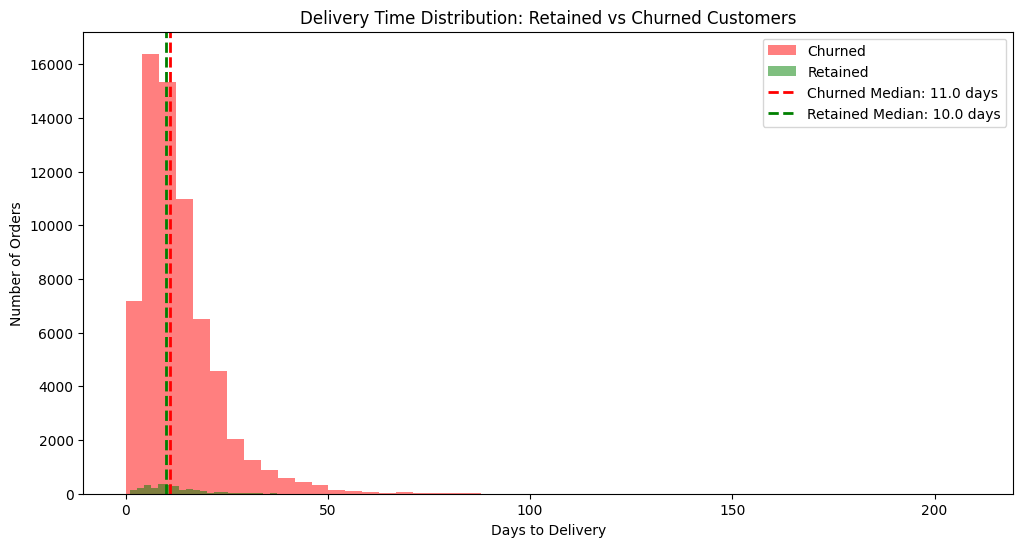

Churned - Median: 11.0 days
Retained - Median: 10.0 days


In [9]:
# Filter to orders with delivery data
delivery_data = bucketed_orders_order_level[bucketed_orders_order_level['time_to_customer'].notna()]
churned_delivery = delivery_data[delivery_data['customer_type'] == 'Churned']['time_to_customer']
retained_delivery = delivery_data[delivery_data['customer_type'] == 'Retained']['time_to_customer']

# Create histogram comparison
plt.figure(figsize=(12, 6))
plt.hist(churned_delivery, bins=50, alpha=0.5, label='Churned', color='red')
plt.hist(retained_delivery, bins=50, alpha=0.5, label='Retained', color='green')
plt.axvline(churned_delivery.median(), color='red', linestyle='--', linewidth=2, 
            label=f'Churned Median: {churned_delivery.median():.1f} days')
plt.axvline(retained_delivery.median(), color='green', linestyle='--', linewidth=2,
            label=f'Retained Median: {retained_delivery.median():.1f} days')
plt.xlabel('Days to Delivery')
plt.ylabel('Number of Orders')
plt.title('Delivery Time Distribution: Retained vs Churned Customers')
plt.legend()
plt.show()

print(f'Churned - Median: {churned_delivery.median():.1f} days')
print(f'Retained - Median: {retained_delivery.median():.1f} days')

**Finding:** Delivery times show virtually no difference between retained and churned customers, with both groups experiencing similar median delivery times. This suggests delivery speed is not a primary driver of retention in this marketplace.


### 4.3 Order Value Analysis

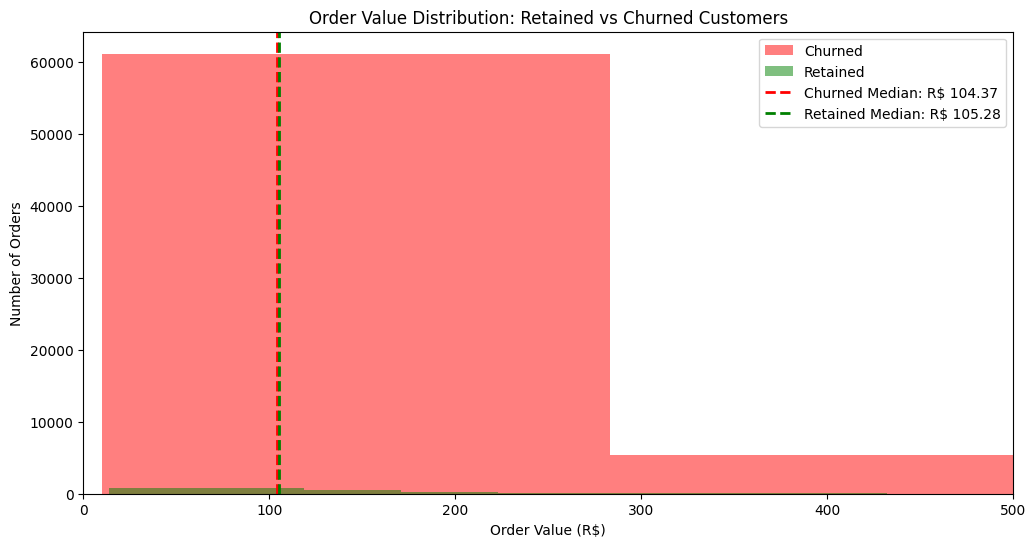

Churned - Median: R$ 104.37
Retained - Median: R$ 105.28


In [10]:
# Calculate total order value per order
order_totals = order_payments.groupby('order_id')['payment_value'].sum().reset_index()
order_totals.columns = ['order_id', 'total_order_value']

# Merge with order-level data
orders_with_value = bucketed_orders_order_level.merge(order_totals, on='order_id', how='left')
orders_unique = orders_with_value.drop_duplicates(subset='order_id')

# Compare order values
churned_value = orders_unique[orders_unique['customer_type'] == 'Churned']['total_order_value']
retained_value = orders_unique[orders_unique['customer_type'] == 'Retained']['total_order_value']

# Create histogram
plt.figure(figsize=(12, 6))
plt.hist(churned_value, bins=50, alpha=0.5, label='Churned', color='red')
plt.hist(retained_value, bins=50, alpha=0.5, label='Retained', color='green')
plt.axvline(churned_value.median(), color='red', linestyle='--', linewidth=2, 
            label=f'Churned Median: R$ {churned_value.median():.2f}')
plt.axvline(retained_value.median(), color='green', linestyle='--', linewidth=2,
            label=f'Retained Median: R$ {retained_value.median():.2f}')
plt.xlabel('Order Value (R$)')
plt.ylabel('Number of Orders')
plt.title('Order Value Distribution: Retained vs Churned Customers')
plt.legend()
plt.xlim(0, 500)
plt.show()

print(f'Churned - Median: R$ {churned_value.median():.2f}')
print(f'Retained - Median: R$ {retained_value.median():.2f}')

**Finding:** Order values show minimal difference between customer segments, suggesting that spend level is not a strong predictor of retention.

### 4.4 Product Category Preferences

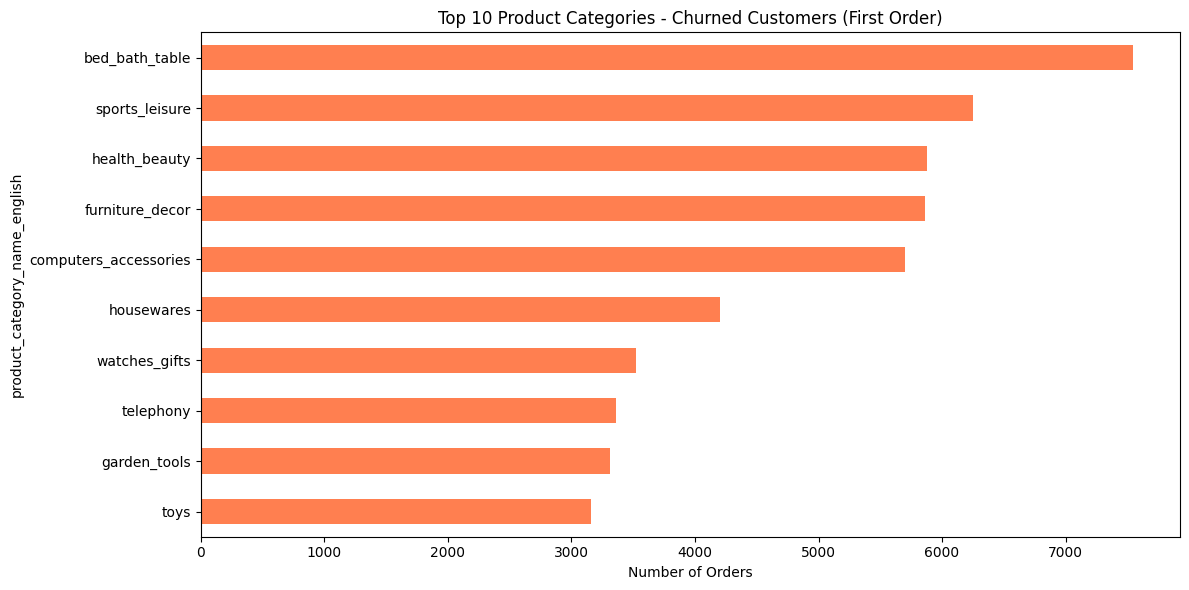

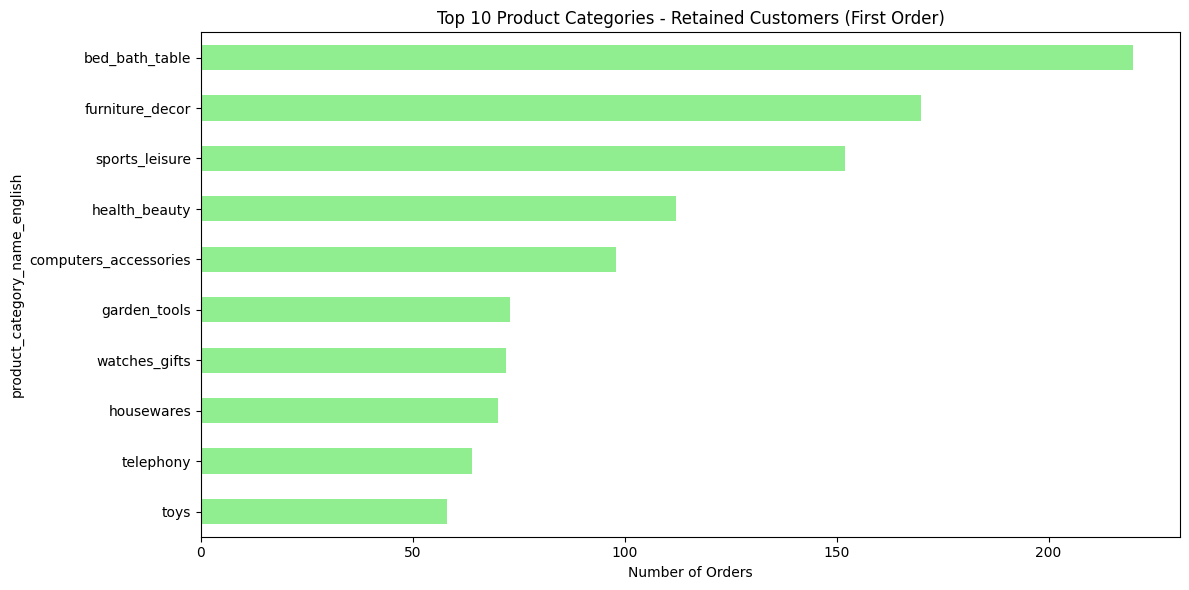


Top 5 Categories - Churned:
product_category_name_english
bed_bath_table           7549
sports_leisure           6251
health_beauty            5879
furniture_decor          5866
computers_accessories    5704
Name: count, dtype: int64

Top 5 Categories - Retained:
product_category_name_english
bed_bath_table           220
furniture_decor          170
sports_leisure           152
health_beauty            112
computers_accessories     98
Name: count, dtype: int64


In [11]:
# Analyze first-order product categories
first_orders_items = bucketed_orders_item_level[
    bucketed_orders_item_level['order_purchase_timestamp'] == bucketed_orders_item_level['first_purchase_date']
]

# Get top categories for churned customers
churned_categories = first_orders_items[first_orders_items['retained'] == False]['product_category_name_english'].value_counts().head(10)

plt.figure(figsize=(12, 6))
churned_categories.plot(kind='barh', color='coral')
plt.title('Top 10 Product Categories - Churned Customers (First Order)')
plt.xlabel('Number of Orders')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Get top categories for retained customers
retained_categories = first_orders_items[first_orders_items['retained'] == True]['product_category_name_english'].value_counts().head(10)

plt.figure(figsize=(12, 6))
retained_categories.plot(kind='barh', color='lightgreen')
plt.title('Top 10 Product Categories - Retained Customers (First Order)')
plt.xlabel('Number of Orders')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print('\nTop 5 Categories - Churned:')
print(churned_categories.head())
print('\nTop 5 Categories - Retained:')
print(retained_categories.head())

**Finding:** Product category preferences show significant overlap between retained and churned customers, with popular categories like bed_bath_table, health_beauty, and sports_leisure appearing prominently in both segments.

### 4.5 Geographic Patterns

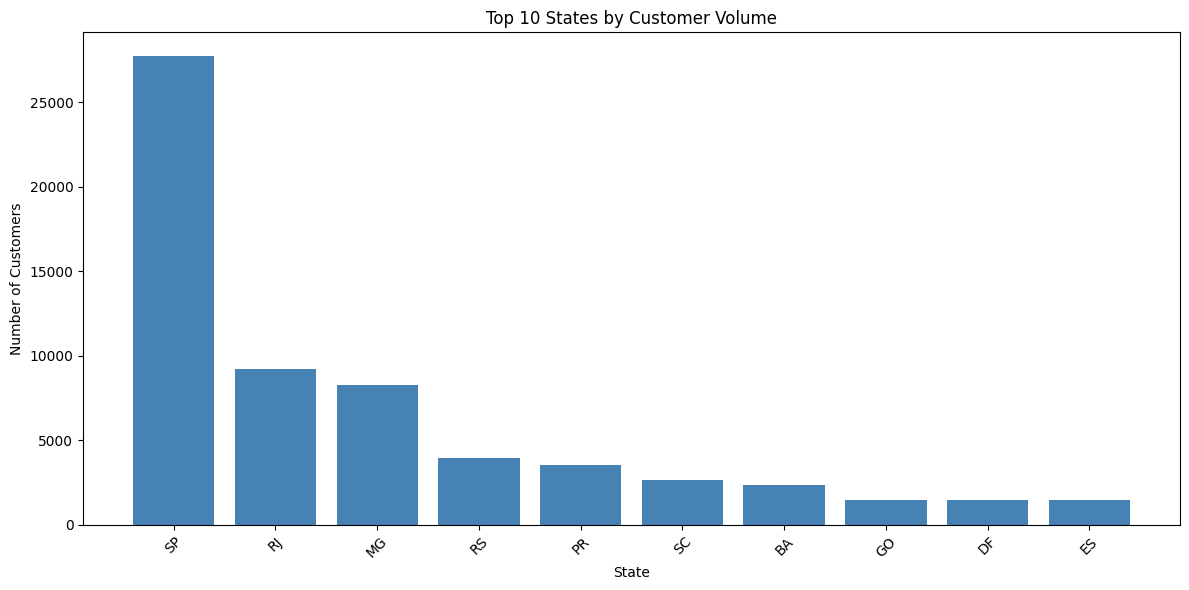

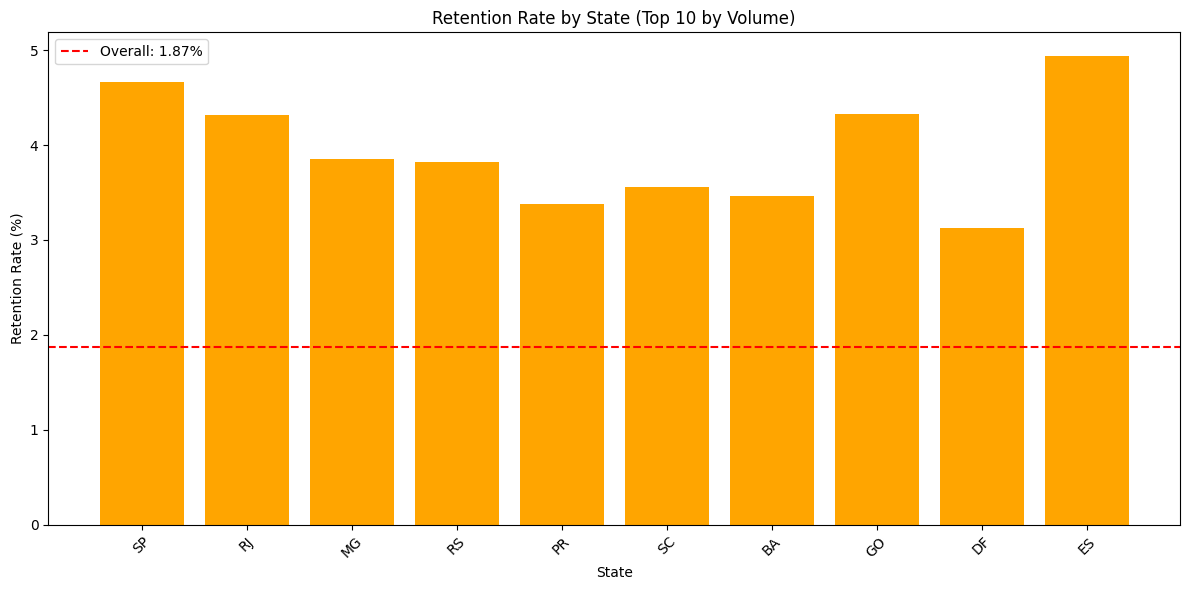


Retention by State (Top 10):
   State  Total_Customers  Retained_Customers  Retention_Rate
25    SP            27756                1293            4.66
18    RJ             9228                 399            4.32
10    MG             8257                 318            3.85
22    RS             3952                 151            3.82
17    PR             3522                 119            3.38
23    SC             2643                  94            3.56
4     BA             2368                  82            3.46
8     GO             1456                  63            4.33
6     DF             1437                  45            3.13
7     ES             1437                  71            4.94


In [12]:
# Analyze retention by state
state_analysis = bucketed_orders_order_level.groupby('customer_state').agg({
    'customer_unique_id': 'nunique',
    'retained': 'sum'
}).reset_index()
state_analysis.columns = ['State', 'Total_Customers', 'Retained_Customers']
state_analysis['Retention_Rate'] = (state_analysis['Retained_Customers'] / state_analysis['Total_Customers'] * 100).round(2)
state_analysis = state_analysis.sort_values('Total_Customers', ascending=False).head(10)

# Customer volume by state
plt.figure(figsize=(12, 6))
plt.bar(state_analysis['State'], state_analysis['Total_Customers'], color='steelblue')
plt.title('Top 10 States by Customer Volume')
plt.xlabel('State')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Retention rate by state
plt.figure(figsize=(12, 6))
plt.bar(state_analysis['State'], state_analysis['Retention_Rate'], color='orange')
plt.axhline(y=retention_rate, color='red', linestyle='--', label=f'Overall: {retention_rate:.2f}%')
plt.title('Retention Rate by State (Top 10 by Volume)')
plt.xlabel('State')
plt.ylabel('Retention Rate (%)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

print('\nRetention by State (Top 10):')
print(state_analysis)

**Finding:** While there is some geographic variation in retention rates, the differences are modest and all states show low retention relative to industry benchmarks. This suggests geographic factors play a limited role in retention patterns.

## 5. Key Findings and Business Implications

### Major Findings

1. **Exceptionally Low Retention Rate (1.87%)**: The Olist marketplace exhibits retention far below typical e-commerce benchmarks, with only 1,292 out of 68,940 eligible customers making repeat purchases within 180 days.

2. **Minimal Operational Differentiation**: Retained customers experience nearly identical:
   - Order approval times
   - Delivery speeds  
   - Delivery accuracy (estimated vs actual)
   - Customer satisfaction scores

3. **Similar Order Characteristics**: Both customer segments show:
   - Comparable order values
   - Similar basket sizes
   - Overlapping product category preferences

4. **Limited Geographic Impact**: While some state-level variation exists, retention remains low across all regions analyzed.

### Business Implications

The lack of clear differentiating factors in transactional data suggests that retention in this marketplace may be driven by:

**1. Specific Product Needs**: Customers may view Olist as a destination for one-time or infrequent purchases rather than a regular shopping destination.

**2. Competitive Marketplace Dynamics**: Brazil's e-commerce landscape is highly competitive. Customers may comparison shop across multiple platforms for each purchase rather than developing platform loyalty.

**3. Marketplace vs Brand Perception**: As a marketplace aggregator rather than a direct retailer, Olist may not build the same brand loyalty that drives retention for single-brand retailers.

**4. Data Limitations**: Important retention drivers such as email marketing engagement, loyalty programs, personalized recommendations, or customer service quality are not captured in this transactional dataset.

### Recommendations

Given the findings, improving retention will likely require strategies beyond operational excellence:

1. **Develop Loyalty Programs**: Create incentives for repeat purchases that go beyond competitive pricing

2. **Category-Specific Strategies**: Focus on categories with naturally recurring purchase patterns (health_beauty, food_drink, pet_shop) where retention might be more achievable

3. **Post-Purchase Engagement**: Implement targeted email campaigns and personalized recommendations to bring customers back

4. **Seller Quality Programs**: While individual seller performance wasn't strongly differentiated, ensuring consistently high seller quality across the marketplace could build trust

5. **First Purchase Experience**: Since operational metrics don't differ, focus on creating memorable brand experiences and emotional connections during the first purchase

### Data Limitations
- Analysis limited to transactional data; lacks marketing engagement, customer service interactions, and competitive shopping behavior
- Dataset spans only 2 years; longer timeframes might reveal different patterns
- Missing context on Olist's market position and competitive landscape during this period